In [65]:
import sys
sys.path.append('../src')

In [66]:
## To reload

import importlib
import data_generation.ground_truth as ground_truth

importlib.reload(ground_truth)

<module 'data_generation.ground_truth' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/notebooks/../src/data_generation/ground_truth.py'>

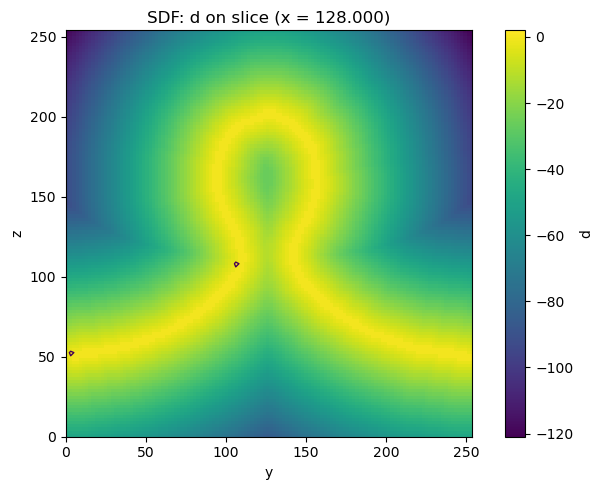

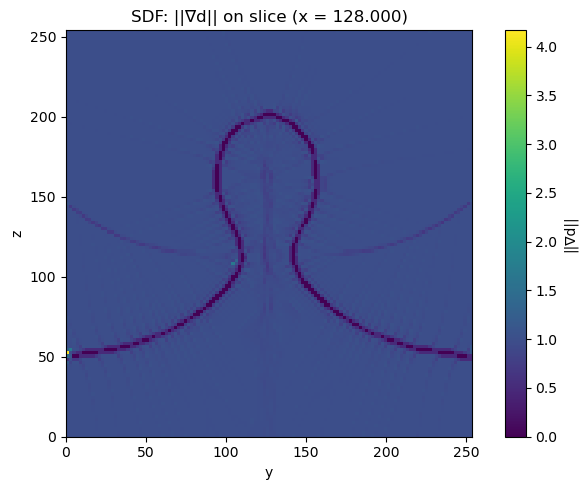

In [4]:
from data_generation.ground_truth import sdf_from_mask, make_d_fn, make_grad_d_fn, visualize_sdf_slice_and_derivative, phi_from_sdf_vals, visualize_phi_slice, visualize_phase_quantities_slice
from data_generation.ground_truth import make_phase_functions, visualize_continuous_slice, sdf_from_surface_mask, sdf_from_open_surface_mask
from pinn.cryoet_io import load_mrc_data
import jax.numpy as jnp

# ---------- Example usage ----------
# Suppose mask is (Z,Y,X) and voxel spacing is (dz,dy,dx) in nm (or any units)

# mrc_file_path = f"../data/synthetic/biconcave.mrc"
mrc_file_path = f"../data/synthetic/bud_04.mrc"
# mrc_file_path = f"../data/synthetic/multi.mrc"
cryoET_data = load_mrc_data(mrc_file_path, grid_size=128)
mask = jnp.where(cryoET_data > 0.8, 1, 0)

# Z,Y,X = 64,64,64
# mask = np.zeros((Z,Y,X), np.uint8)
# mask[28:36, 28:36, 28:36] = 1   # a tiny cube as "membrane" just for demo
spacing = (2.0, 2.0, 2.0)       # e.g., 2 nm voxels
origin  = (0.0, 0.0, 0.0)       # world coords of voxel (0,0,0)

# D = sdf_from_mask(mask, spacing=spacing, sign_convention="outside_positive")
# D = sdf_from_surface_mask(mask, spacing=spacing)
D = sdf_from_open_surface_mask(mask, spacing=spacing)
# d_fn = make_d_fn(D, origin, spacing)
# phi, grad_phi, lap_phi, E, R2 = make_phase_functions(D, origin, spacing, eps)

eps = 2
visualize_sdf_slice_and_derivative(D, origin=origin, spacing=spacing, axis='x')
# visualize_phi_slice(D, eps, origin, spacing, axis='x', index=None, title_prefix="φ")
# visualize_phase_quantities_slice(D, eps, origin=origin, spacing=spacing, axis='x', index=None, title_prefix="My Membrane")
# visualize_continuous_slice(D, origin=origin, spacing=spacing, eps=eps, axis='x', index=None, n=None, title_prefix="My membrane")


In [80]:
# membrane: (Z,Y,X) numpy array, 1 = membrane, 0 = background

from pinn.cryoet_io import load_mrc_data
from data_generation.ground_truth import volume_on_one_side, add_boundary_wall, split_by_membrane_side
import numpy as np

GRID_SIZE = 128
shape = "biconcave"
mrc_path = f"../data/synthetic/{shape}.mrc"
cryoET_data = load_mrc_data(mrc_path, grid_size=GRID_SIZE)
thresholded = np.asarray(cryoET_data > 0.8)  # make sure it's numpy
# thresholded = add_boundary_wall(thresholded, thickness=2)



vols, info, masks = split_by_membrane_side(
    thresholded,
    inside_face="ymin",      # choose which side you call "inside"
    close_holes=0,           # optional
    connectivity=6,
    return_masks=True,
)
print(info)
print(vols)

# volume, info, masks = volume_on_one_side(
#     # cryoET_data,
#     thresholded,
#     voxel_size=(2.0/GRID_SIZE),
#     side="inside",
#     close_holes=1,
#     return_masks=True,
# )

# print("Inside volume:", volume)
# print(info)


# vol, info, masks = volume_on_one_side(membrane, return_masks=True)
print("inside voxels:", info["n_inside"])
print("outside voxels:", info["n_outside"])
print("membrane voxels:", masks["membrane"].sum())



{'inside_face': 'ymin', 'connectivity': 6, 'close_holes': 0, 'include_membrane_in_inside': True, 'voxel_size': 1.0, 'n_inside': 1934413, 'n_outside': 162739, 'n_membrane': 48992}
{'inside': 1934413.0, 'outside': 162739.0, 'membrane': 48992.0}
inside voxels: 1934413
outside voxels: 162739
membrane voxels: 48992


(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'MIP XY'}>,
        <Axes: title={'center': 'MIP XZ'}>,
        <Axes: title={'center': 'MIP YZ'}>], dtype=object))

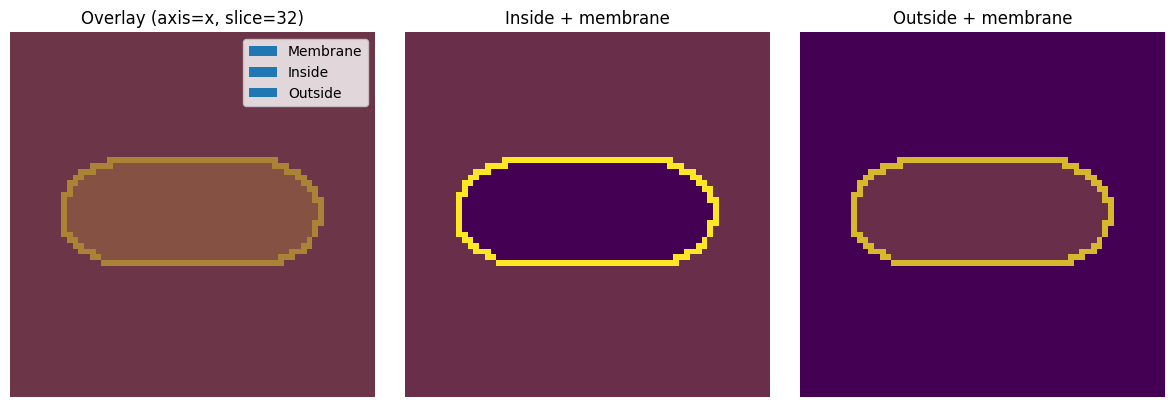

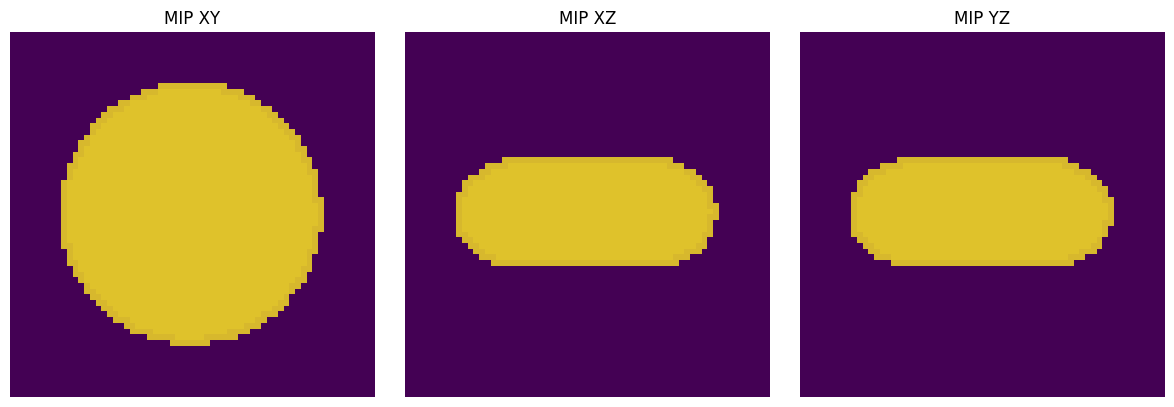

In [79]:
from data_generation.ground_truth import visualize_volume_slices, visualize_volume_projections

visualize_volume_slices(
    membrane=masks["membrane"],
    inside=masks["inside"],
    outside=masks["outside"],
    axis="x",
    slice_index=32,
)

visualize_volume_projections(
    membrane=masks["membrane"],
    inside=masks["inside"],
    outside=masks["outside"],
)

In [92]:
## Calculate volume of bud_04
import os
from flax.training import checkpoints
from pinn.utils import _PINN
import jax
from pinn.model import phase_volume

## ===== LOAD PHASE FIELD ========
shape = "bud_04"
data_type = "data_0926/clean/sphere"
lambda_1 = 1000000
lambda_2 = 50
step = 10000
checkpoint_dir = os.path.abspath(f"../outputs/logs/{shape}/{data_type}/lambda_{lambda_1}_{lambda_2}")
checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_{step}")
ckpt_dat = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)

num_point = 10000

key = jax.random.PRNGKey(0)
sample_points = jax.random.uniform(key, (num_point, 3), minval=-1, maxval=1)

state  = ckpt_dat["state"]
params = state["params"]
model  = _PINN()
phi_fn = lambda x: model.apply(params, x)

value = phase_volume(phi_fn, sample_points)
print("volume: ", value)

volume:  1.9403676
